# Nettoyage des données : House Prices

## Objectif
Charger le dataset brut, explorer sa structure, identifier et traiter les valeurs manquantes et les incohérences avant modélisation.

## Étapes
1. Chargement du dataset
2. Aperçu général (dimensions, types, valeurs manquantes)
3. Traitement des valeurs manquantes
4. Vérification des types de données
5. Vérification des doublons
6. Détection des valeurs aberrantes (outliers)
7. Vérification de l'asymétrie (skewness) de la variable cible
8. Export du dataset nettoyé vers `data/processed/`

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('../data/raw/train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [22]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(2)})

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [23]:
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
             'GarageCond', 'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'MasVnrType']
for col in cols_none:
    df[col] = df[col].fillna('None')

In [24]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


In [25]:
print(df.isnull().sum().sum(), "valeurs manquantes restantes")

0 valeurs manquantes restantes


In [26]:
df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [27]:
df[['MSSubClass', 'OverallQual', 'OverallCond', 'YrSold', 'MoSold']].dtypes

MSSubClass     int64
OverallQual    int64
OverallCond    int64
YrSold         int64
MoSold         int64
dtype: object

In [28]:
cols_to_categorical = ['MSSubClass','YrSold','MoSold']
df[cols_to_categorical] = df[cols_to_categorical].astype(str)

df[cols_to_categorical].dtypes

MSSubClass    object
YrSold        object
MoSold        object
dtype: object

In [29]:
print(df.duplicated().sum(), "lignes dupliquées")
print(df['Id'].duplicated().sum(), "Id dupliqués")

0 lignes dupliquées
0 Id dupliqués


In [30]:
numeric_cols = df.select_dtypes(include='number').columns.drop('Id')
numeric_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'SalePrice'],
      dtype='object')

In [31]:
outliers_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] > upper) | (df[col] < lower)).sum()
    outliers_summary[col] = count

outliers_df = pd.Series(outliers_summary).sort_values(ascending=False)
outliers_df[outliers_df > 0]

EnclosedPorch    208
BsmtFinSF2       167
OverallCond      125
ScreenPorch      116
MasVnrArea        98
LotFrontage       93
BsmtHalfBath      82
GarageYrBlt       81
OpenPorchSF       77
LotArea           69
KitchenAbvGr      68
SalePrice         61
TotalBsmtSF       61
MiscVal           52
BedroomAbvGr      35
WoodDeckSF        32
GrLivArea         31
TotRmsAbvGrd      30
BsmtUnfSF         29
LowQualFinSF      26
3SsnPorch         24
GarageArea        21
1stFlrSF          20
BsmtFinSF1         7
PoolArea           7
YearBuilt          7
GarageCars         5
Fireplaces         5
OverallQual        2
2ndFlrSF           2
BsmtFullBath       1
dtype: int64

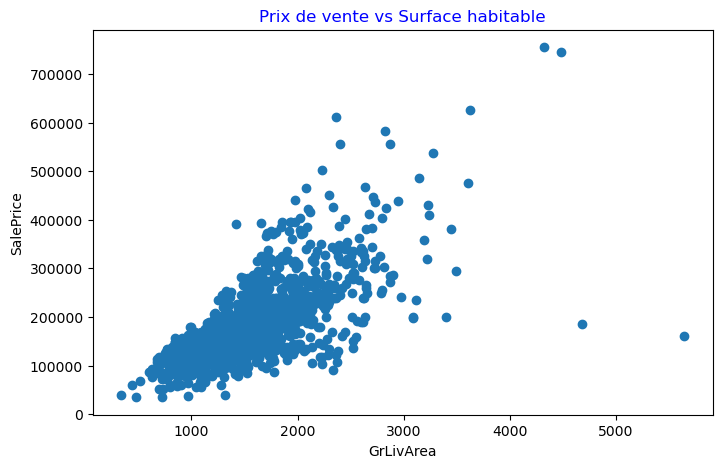

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('Prix de vente vs Surface habitable', color='blue')
plt.show()

In [33]:
df = df[df['GrLivArea'] < 4500]
print(df.shape)

(1458, 81)


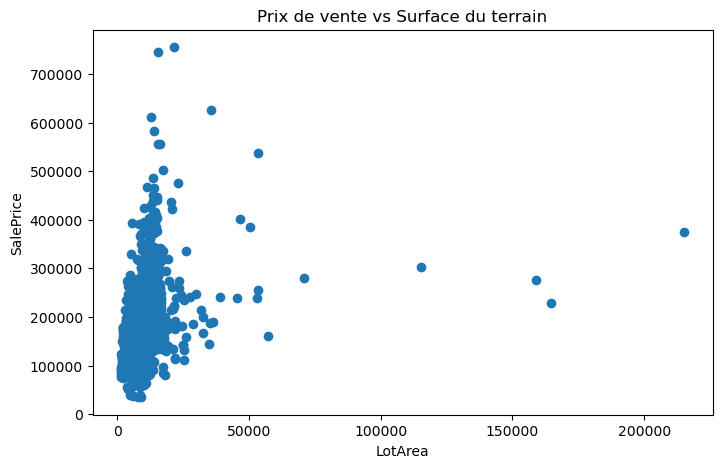

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df['LotArea'], df['SalePrice'])
plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.title('Prix de vente vs Surface du terrain')
plt.show()

In [35]:
df.shape

(1458, 81)

In [36]:
from scipy.stats import skew
print("Skewness de SalePrice :", skew(df['SalePrice']))

Skewness de SalePrice : 1.8793604459195012


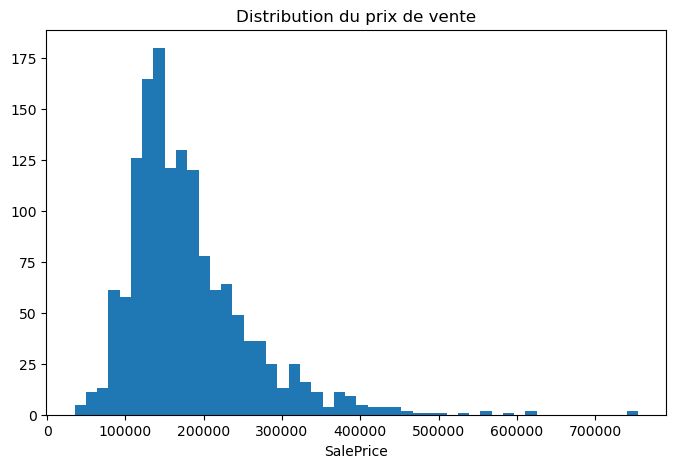

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=50)
plt.xlabel('SalePrice')
plt.title('Distribution du prix de vente')
plt.show()

In [38]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])
print('Skewness après transformation log :', skew(df['SalePrice_log']))

Skewness après transformation log : 0.1214546426818453


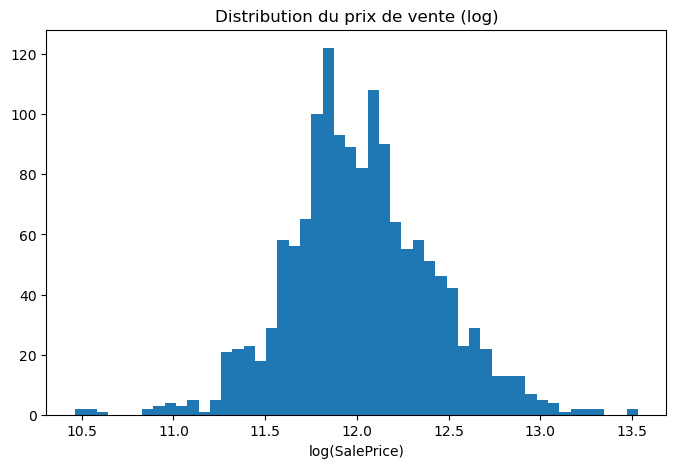

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice_log'], bins=50)
plt.xlabel('log(SalePrice)')
plt.title('Distribution du prix de vente (log)')
plt.show()

In [40]:
df.to_csv('../data/processed/train_cleaned.csv', index=False)
print('Fichier exporté avec succès')

Fichier exporté avec succès
